In [154]:
from IPython import get_ipython
from IPython.display import display

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from statistics import mean
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import math
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import time
from keras.models import load_model
import pickle
from IPython import get_ipython
from IPython.display import display

import math
import scipy.constants as constant


In [155]:
import math
import scipy.constants as constant
import random as rand
from scipy.stats import truncnorm


In [156]:

# Carrier Frequency

FC = 2.4e9
Glos = 1
C = constant.c
Lamda = 2.5
# Lamda = (C/FC)
IRS_Count = 3
NIRS = 3
# # Speed of Light
# K = 10

# Power Spectral Density
N0 = 1e-20

# Bandwidth
B = 1e6
eta_LOS = 0.1 #Suburban
eta_NLOS = 21 #Suburban

# Noise
STD = B * N0

# Environmental Variable 1
B11 = 4.88

# Environmental Variable 2
B21 = 0.43

# Environmental Variable 1
B1 = 0.36

# Environmental Variable 2
B2 = 0.21

# Path Loss Exponent
ALPHA = 2

# Additional path loss for LineOfSight
U_LOS = 10**(3/10)

# Additional path loss for NonLineOfSight
U_NLOS = 10**(23/10)

K0 = (4 * math.pi * FC / C) ** 2
Location_GBS =[0,100]


# Environmental Variable 3
ZETA = 0

# Transmission power of an UAV
P = 100
Ggbs = 10
Guav = 5
Pan = 0
# Discount Rate
GAMMA = 0.95

# Learning Rate
LR = 0.001

# Initial Epsilon Greedy Value
EPSILON = 1

# Epsilon Greedy Decay Rate
EPSILON_DECAY = 0.95

# Minimum Epsilon Greedy
EPSILON_MIN = 0.1

# Minimum altitude to fly
MIN_ALTITUDE = 100

# Initial Altitude
ALTITUDE = 200

# Maximum altitude to fly
MAX_ALTITUDE = 400

# Penalty value
PENALTY = -100
spy_count = 5
random = False
# UAV speed rate according to humans
UAV_MOVEMENT_SCALE= 30

STEP_COUNT_TRAINED_ON = 64
UNIT =20
UE_COUNT = 200

env_dim = (100,100)

alt = ALTITUDE
mid_height, mid_width = env_dim[1]//2, env_dim[0]//2


In [157]:
Number_of_irs_per_side = 20
MOVEMENT_VECTORS = [(1,0), (-1,0), (0,1), (0,-1)]
BTS_path = [[0,40]]


In [158]:
from statistics import mean
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import math
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import time
from keras.models import load_model
import pickle

sns.set_style("darkgrid")

In [159]:

# Helper Function for normal distribution
def get_truncated_normal(mean=0, low=0, upp=10):
    return truncnorm(
        (low - mean), (upp - mean), loc=mean, scale=1).rvs()

# Normal Distribution
def gaussian(end,begin=0):
    normal_random = round(get_truncated_normal(mean=int((begin+end)/2),low=begin,upp=end))
    return max(0,min(normal_random,end))

In [160]:
class Agent():

    def __init__(self,state_size,action_count,batch_size=200,maxlen=10000):

        self.batch_size = batch_size
        self.input_size   = state_size
        self.action_count = action_count
        self.lr = LR
        self.gamma = GAMMA #Discount factor = continuous tasklarda return'un sonsuza gitmemesi için
        self.epsilon = EPSILON
        self.epsilon_decay = EPSILON_DECAY
        self.epsilon_min = EPSILON_MIN
        self.model = self.build_model()
        self.memory = deque(maxlen=maxlen)

    def build_model(self):
        """
            Create Neural network as Deep Q Network
        """
        model = Sequential()
        model.add(Dense(128, input_dim= self.input_size, activation = "relu"))
        model.add(Dense(64,activation="relu"))
        model.add(Dense(64,activation="relu"))
        model.add(Dense(64,activation="relu"))
        model.add(Dense(64,activation="relu"))
        model.add(Dense(self.action_count,activation="linear"))
        model.compile(Adam(learning_rate = self.lr ,clipnorm=1.0),loss=Huber())
        return model


    def store(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))


    def act(self,state,cannot_random=False):    #state = [[[50 50 50 50 50 50 64]], [[[0. 0. 0. ... 0. 0. 0.],  [0. 0. 0. ... 0. 0. 0.],  [0. 0. 0. ... 0. 0. 0.],  ...,  [0. 0. 0. ... 0. 0. 0.],  [0. 0. 0. ... 0. 0. 0.],  [0. 0. 0. ... 0. 0. 0.]]]]

        if ((not cannot_random) or random):
            return rand.randint(0,self.action_count-1)
        else:
            act_values = self.model.predict(state) #[[6.2040935  0.96265495 2.69465    3.8230026  3.2360513  4.705814,  0.4720979 ]]
            return np.argmax(act_values[0])



    def is_memory_enough(self):
        return not (len(self.memory)< self.batch_size)


    def replay(self):

        if(not self.is_memory_enough()):
            return

        minibatch = rand.sample(self.memory,self.batch_size)

        for state,action, reward,next_state, done in minibatch:

          if done:
            target = reward
          else:
            target = reward + self.gamma*np.amax(self.model.predict(next_state))

          train_target = self.model.predict(state)
          train_target[0][action] = target

          self.model.fit(state,train_target,verbose=0)


    def adaptiveEGreedy(self):
        if(self.epsilon > self.epsilon_min and self.is_memory_enough()):
            self.epsilon *= self.epsilon_decay

In [161]:

# General class for moving objects
class MovingObject():
    def __init__(self,initial_location):
        self.current_location = initial_location.copy()
        self.starting_location = initial_location.copy()


    def reset(self):
        self.current_location = self.starting_location.copy()


# Uav class
class UAV(Agent,MovingObject):

    def __init__(self,state_size,action_count,batch_size,initial_location,maxlen=10000):
        Agent.__init__(self,state_size,action_count,batch_size=batch_size,maxlen=maxlen)
        MovingObject.__init__(self,initial_location)
        self.transmission_power = P
        self.distance_GBS = 0


# User Class
class UE(MovingObject):

    def __init__(self,initial_location,env_dim,movement_vectors,define_path_first = True,step_count = 10000,movement_function=gaussian):
        super().__init__(initial_location)

        self.movement_vectors =movement_vectors[:5].copy()  # altitude vektörleri hariç
        rand.shuffle(self.movement_vectors)

        self.movement_function = movement_function
        self.maxY , self.maxX = env_dim
        self.path = []
        self.path_determined = define_path_first

        if define_path_first:
            self.initial = 0
            for _ in range(step_count):
                self.path.append(movement_function(len(self.movement_vectors)-1))

    def move(self):
        action_index = 0

        if self.path_determined:
            action_index = self.path[self.initial]

            self.initial+=1
            if self.initial==len(self.path):
                self.initial = 0
        else:
            action_index = self.movement_function(len(self.movement_vectors)-1)


        action = self.movement_vectors[int(action_index)]
        self.current_location= [self.current_location[i] + action[i] for i in range(2)]



from statistics import mean
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import math
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import time
from keras.models import load_model
import pickle

sns.set_style("darkgrid")


In [162]:
# Số phần tử IRS
M = 16

# Số người dùng
N = 2

# Công suất phát của BTS
P = 1.0
# sô ăng teng phát
BT = 1

# Hệ số suy hao kênh
beta_BS_IRS = 1.0
beta_IRS_UE = 1.0

# Hệ số Rician (tỷ lệ LoS/NLoS)
K = 10.0

# Nhiễu tại người dùng
sigma_u2 = 0.01

alpha_c = 0.5
alpha = [(1 - alpha_c) / N for _ in range(N)]
lamda= 2.5

# Main Environment
class UavSimuEnv:
    actions = [(1,0),(-1,0),(0,0),(0,1),(0,-1)] #Actionlar
    coord_count = 2

    def __init__(self,uav_paths,ue_paths,env_dim = (100,100),batch_size=200,max_memory_per_agent=10000,uav_class=UAV,ue_class=UE):
        self.step_count = STEP_COUNT_TRAINED_ON
        self.uav_count = len(uav_paths)
        self.env_dim = env_dim
        self.input_size = self.get_input_size(len(uav_paths))
        self.map = {"uav_set": self.init_uav(uav_paths,batch_size,max_memory_per_agent,uav_class),
                    "ue_set": [ue_class(initial_location=ue_path, env_dim=env_dim, movement_vectors=MOVEMENT_VECTORS) for ue_path in ue_paths]}

    def init_uav(self,uav_paths,batch_size,max_memory_per_agent,uav_class):
        """
        Agent'ları initialize eder
        """
        return [uav_class(self.input_size, len(self.actions), batch_size, begin,maxlen=max_memory_per_agent)
                for begin in uav_paths]

    def get_all_uavs(self):
            return [uav for uav in self.map["uav_set"]]

    def distance_func(self,v1,v2):
        return (sum(((p - q) * UNIT) ** 2 for p, q in zip(v1[:1], v2[:1])) ) ** 0.5

    def distance_funcGBS(self, v1, v2):
        distance = ((v1[0] - v2[0]) ** 2 + (v1[1] - v2[1]) ** 2 ) ** 0.5
        return distance
    def get_distance_list(self, dest_list, location,isObject=False):
        """
        Return distance list of distance between the locations in dest;_list and given location
        """
        if (isObject):
            return [self.distance_func(location,loc.current_location) for loc in dest_list]
        return [self.distance_func(location,loc) for loc in dest_list]


    def get_distance_matrix(self,map_obj=None):
        """
        Return all distance matrix and association count vector between UAV-UE
        """
        if(map_obj==None):
            map_obj = self.map

        def minIndex(lst):
            return lst.index(min(lst))

        def get_distances(lst1, lst2, isLst2Object = True):
            distance_matrix = []
            assoc_matrix = []
            for _ in range(len(lst2)):
                assoc_matrix.append([])

            for index,member in enumerate(lst1):
                distances = self.get_distance_list(lst2,member.current_location,isLst2Object)
                distance_matrix.append(distances)
                index_of_min = minIndex(distances)
                assoc_matrix[index_of_min].append(index)

            return distance_matrix, assoc_matrix

        ue_uav_matrix, assoc_matrix_uav = get_distances(map_obj["ue_set"],map_obj["uav_set"])

        return {"ue_uav_matrix": ue_uav_matrix, "assoc_matrix_uav" : assoc_matrix_uav}

    def save(self,env_name):
        for index,uav in enumerate(self.get_all_uavs()):
            model = uav.model
            path = "modelss/{}/".format(env_name)
            if not os.path.exists(path):
                os.makedirs(path)
            model_name = "{}uav{}".format(path,index)
            model.save(model_name+".h5")
            pickle.dump(uav.memory, open(model_name+"memory.pkl", 'wb'))
            print(path)

    def load(self, path, just_for_test=True, load_memory=False):
        for index in range(len(self.map["uav_set"])):
            model_name = "{}/uav{}".format(path, index)
            self.getUAV(index).model = keras.models.load_model(model_name + ".h5", compile=not just_for_test)
            if (load_memory):
                self.getUAV(index).memory = pickle.load(open(model_name + "memory.pkl", "rb"))

    def reset(self):
        """
        Reset Environment
        """
        def reset_set(key):
            for index, val in enumerate(self.map[key]):
                self.map[key][index].reset()

        reset_set("ue_set")
        reset_set("uav_set")
        self.initial_time = 0

    def get_input_size(self,uav_count):
        return uav_count*self.coord_count + math.ceil(self.step_count/UAV_MOVEMENT_SCALE)

    def is_collect_step(self):
        return self.getUAV(0).is_memory_enough()

    def get_current_epsilon(self):
        return self.getUAV(0).epsilon

    def reshape(self, data):
        return np.reshape(data, [1,self.input_size])

    def get_state_input(self,isNext=False):
        """
        Return state information for UAV
        """
        all_uav_coordinates = []

        for uav in self.map["uav_set"]:
            all_uav_coordinates.extend(uav.current_location[:self.coord_count])

        time_range = [0 for _ in range(math.ceil(self.step_count/UAV_MOVEMENT_SCALE))]
        print(self.initial_time // UAV_MOVEMENT_SCALE)
        print(self.initial_time)
        time_range[self.initial_time // UAV_MOVEMENT_SCALE] = 1
        return self.reshape(all_uav_coordinates +time_range)

    def caculate_theta(self, n):
        # Tạo mảng các giá trị từ 0 đến 2pi
        values = np.linspace(0, 2 * np.pi, n)

        # Tạo ma trận đường chéo với các giá trị này
        diagonal_matrix = np.diag(values)

        return diagonal_matrix


    def check_condition(alpha_list, alpha_c):
        """
        Kiểm tra điều kiện: sum(alpha_i + alpha_c) = 1

        Args:
            alpha_list (list): Danh sách các giá trị alpha_i (N phần tử)
            alpha_c (float): Giá trị alpha_c

        Returns:
            bool: True nếu điều kiện thỏa mãn, ngược lại False
        """
        total = sum(alpha_list) + len(alpha_list) * alpha_c
        return abs(total - 1) < 1e-6  # So sánh với sai số nhỏ



    def rician_fading(self, K_factor, beta, size, d=1.0):
        if isinstance(size, (int, float)):
            size = (int(size),)
        if isinstance(d, tuple):
            d = np.linalg.norm(d)

        LoS = np.exp(1j * 2 * np.pi * np.random.rand(*size))
        NLoS = (np.random.randn(*size) + 1j * np.random.randn(*size)) / np.sqrt(2)
        H = (d ** (-lamda)) * np.sqrt(beta) * (
            np.sqrt(K_factor / (K_factor + 1)) * LoS + np.sqrt(1 / (K_factor + 1)) * NLoS
        )
        return H

    def calculate_sum_rate(self,map_obj=None):
        if(map_obj==None):
                map_obj = self.map



        # Kênh từ BTS → IRS
        size = (M, BT)
        G_BS_IRS = self.rician_fading(10.0, beta_BS_IRS,size, 1.0)

        # Kênh từ IRS → User (giả sử có N người dùng)
        H_IRS_UE = np.array([self.rician_fading(10.0, beta_IRS_UE, size,1.0) for _ in range(N)])


        # Chuyển thành ma trận chéo
        Theta = self.caculate_theta(M)  # (M, M)

        def dot_fuc(a, b,c) :
            return a.reshape(BT, M) @ b @ (c.reshape(M,BT))

        # # Tín hiệu nhận được tại user i
        # def received_signal(i):
        #     G = G_BS_IRS.reshape(BT, M)  # Chuyển thành vector hàng (1, M)
        #     H = H_IRS_UE[i].reshape(M, BT)        # Chuyển thành vector cột (M, 1)
        #     return G @ Theta @ H @ W_c  # Kết quả là một số phức

        def compute_beamforming(theta):
            """ Tính toán beamforming vector W theo MRT """
            # Theta_H = Theta.conj().T  # Ma trận phức liên hợp chuyển vị
            wi = []
            for i in range(N):
                num = dot_fuc(H_IRS_UE[i], theta, G_BS_IRS)  # (BT,1)
                den = np.linalg.norm(dot_fuc(G_BS_IRS, theta, H_IRS_UE[i]))  # Số vô hướng
                wi.append(num / den)  # Kích thước (BT,1)

            # Tính W_i
            # Wi = (H_BS_IRS.reshape(1,M) @ theta_H @ G_IRS_UE) / np.linalg.norm(G_IRS_UE[i].reshape(M,1).T @ theta_H @ H)

            # Tính W_c
            sum_terms = np.sum([ dot_fuc(H_IRS_UE[i], theta, G_BS_IRS)for i in range(N)], axis=0)
            wc = sum_terms / np.linalg.norm(sum_terms)  # (BT,1)

            return wi, wc

        Wi, Wc = compute_beamforming(Theta)  # Khởi tạo Wi và Wc
        # Tính SINR
        def compute_sinr(i):
            """ Tính SINR theo công thức RMSA (Rate-Splitting Multiple Access) """

            # Tính SINR_c (TIN hiệu chung)
            num_c = P * alpha_c * np.linalg.norm(dot_fuc(G_BS_IRS, Theta, H_IRS_UE[i]) @ Wc) ** 2
            denom_c = sum(P * np.linalg.norm(dot_fuc(G_BS_IRS, Theta, H_IRS_UE[i]) @ Wi[i]) ** 2 for i in range(N)) + sigma_u2
            sinr_c = num_c / denom_c  # SINR của tín hiệu chung

            # Tính SINR_p_i (TIN hiệu riêng của user i)
            sinr_p = []
            for i in range(N):
                num_p_i = P * alpha[i] * np.linalg.norm(dot_fuc(G_BS_IRS, Theta, H_IRS_UE[i]) @ Wi[i]) ** 2
                denom_p_i = P * alpha[i]* sum(np.linalg.norm(dot_fuc(G_BS_IRS, Theta, H_IRS_UE[j]) @ Wi[j]) ** 2 for j in range(N) if j != i) + sigma_u2
                sinr_p.append(num_p_i / denom_p_i)  # SINR riêng của user i

            return sinr_c, sinr_p

        SINR_c = []  # Lưu SINR của tín hiệu chung
        SINR_p = []  # Lưu SINR của tín hiệu riêng

        for i in range(N):
            sinr_c, sinr_p = compute_sinr(i)
            SINR_c.append(sinr_c)
            SINR_p.append(sinr_p)

        def compute_rate(SINR_c_dB, SINR_p_dB):
            """
            Tính toán achievable rate dựa trên SINR đầu vào.

            Tham số:
                - SINR_c_dB: Mảng 1D (N,) chứa SINR của tín hiệu chung (dB).
                - SINR_p_dB: Mảng 2D (N,N) chứa SINR của tín hiệu riêng (dB).

            Trả về:
                - R_ci: Mảng 1D (N,) chứa rate của tín hiệu chung.
                - R_pi: Mảng 2D (N,N) chứa rate của tín hiệu riêng.
                - R_total: Tổng Rate tính theo công thức.
            """

            # Chuyển SINR từ dB sang giá trị tuyến tính
            SINR_c = 10 ** (np.array(SINR_c_dB) / 10)
            SINR_p = 10 ** (np.array(SINR_p_dB) / 10)

            # Tính Achievable Rate
            R_ci = np.log2(1 + SINR_c)  # Rate của tín hiệu chung
            R_pi = np.log2(1 + SINR_p)  # Rate của tín hiệu riêng


            # Tính tổng Rate
            R_total = np.min(R_ci) + np.sum([R_pi[i][i] for i in range(N)])

            return R_total

        return compute_rate(SINR_c,SINR_p)   #R_ci, R_pi, R_total


    def step_UEs(self):
        """
        Move all UEs in Simulation
        """
        ue_set_length = len(self.map["ue_set"])
        for ue in self.map["ue_set"]:
            ue.move()

        if (not self.isInside(ue.current_location,True)):
            self.map["ue_set"].remove(ue)


    def isCollides(self,uav_index,new_location):
        """
        check if location is against limits
        """
        for index,uav in enumerate(self.map["uav_set"]):
            if(index!=uav_index and np.array_equal(uav.current_location, new_location)):
                return True
        return False


    def step_env(self,action_indexes):
        """
        Change environment with given joint actions
        """
        old_sum_rate = self.calculate_sum_rate()
        penalty = 0
        done = False
        for uav_index in range(len(self.map["uav_set"])):
            current = self.getUAV(uav_index).current_location
            action_index = action_indexes[uav_index]
            new_location = [current[i] + self.actions[action_index][i] for i in range(3)]
            self.getUAV(uav_index).current_location = new_location

        for uav_index in range(len(self.map["uav_set"])):
            if(self.isCollides(uav_index,self.getUAV(uav_index).current_location)):
                done = True
                penalty +=PENALTY

        new_sum_rate = self.calculate_sum_rate()

        reward = new_sum_rate-old_sum_rate + penalty #penalty negatif
        done = done or self.initial_time == self.step_count
        return self.get_state_input(), reward, done

    def getUAV(self,uav_index):
        return self.map["uav_set"][uav_index]


    def step_UAVs(self,isTest=False,isCollectStep=False):
        """
        Move all UAVs
        """
        uav_set_length = len(self.map["uav_set"])

        state = self.get_state_input()

        action_indexes = [self.getUAV(uav_index).act(state,cannot_random = isTest) \
                for uav_index in range(uav_set_length)]

        next_state, reward, Done = self.step_env(action_indexes)

        if(not isTest):
            for uav_index in range(uav_set_length):
                self.getUAV(uav_index).store(state,action_indexes[uav_index],reward,next_state,Done)

                if(not isCollectStep):
                    self.getUAV(uav_index).replay()
                    if(self.initial_time==self.step_count-1):
                        self.getUAV(uav_index).adaptiveEGreedy()
        self.initial_time +=1

    def isInside(self,location,isOnGround=False):
        """
        Return if location is against the limits
        """
        return (0 <= location[0] < self.env_dim[1] and 0<= location[1] < self.env_dim[0] ) \
                and (isOnGround or  MIN_ALTITUDE <= location[2] <= MAX_ALTITUDE)

    def reshape(self, data):
        return np.reshape(data, [1,self.input_size])


    def isInside(self,location,isOnGround=False):
        """
        Return if location is against the limits
        """
        return (0 <= location[0] < self.env_dim[0] ) \
                and (isOnGround or  MIN_ALTITUDE <= location[1] <= MAX_ALTITUDE)

    def get2DMap(self):
        def getCoords(map):
            x,y = [],[]
            for obj in map:
                x.append(obj.current_location[0])
                y.append(obj.current_location[1])

            return x,y
        return getCoords(self.map["uav_set"]),getCoords(self.map["ue_set"])


    def render(self):

        """
        Render simulation visually
        """
        fig, ax = plt.subplots(figsize = (10,10))
        uav_coords, ue_coords = self.get2DMap()

        clear_output(wait= True)
        ax.set_xlim(0, self.env_dim[0])
        ax.set_ylim(0, self.env_dim[1])
        print("UAV Coordinates:", uav_coords)
        print("UE Coordinates:", ue_coords)


        #ve may bay khong nguoi lai
        ax.scatter(uav_coords[0], uav_coords[1], color='green',label="UAV")

        # draw user equipments
        ax.scatter(ue_coords[0], ue_coords[1], c='red', label="UEs")

        #draw lines between uav and ues
        distance_map = self.get_distance_matrix()["assoc_matrix_uav"]
        for uav_index in range(self.uav_count):
            coord_of_UAV = self.getUAV(uav_index).current_location
            for ue_index in distance_map[uav_index]:
                coord_of_UE = self.map["ue_set"][ue_index].current_location  # Chỉ lấy x, y
                ax.plot([coord_of_UE[0], coord_of_UAV[0]], [coord_of_UE[1], coord_of_UAV[1]], c="green", alpha=0.1)

        ax.legend()
        plt.xlabel("X Coordinate")
        plt.ylabel("Y Coordinate")
        plt.title("2D UAV-UE Association")
        plt.grid(True)
        plt.show()



In [163]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from keras.optimizers import Adam
import multiprocessing
from joblib import Parallel, delayed

In [164]:


def plot_iter_graph(ignore_count,sum_rates_per_iteration):
    plt.plot(sum_rates_per_iteration[ignore_count:])
    plt.title("Sum rates per iteration")
    plt.show(sum_rates_per_iteration)

def plot_step_graph(iteration_num, step_num,step_count,sum_rates_per_step):
    print(sum_rates_per_step)
    if (iteration_num >= 1):
        if (step_num >1):
            begin_iter = max(0,iteration_num-5)
            x_pivot = begin_iter*step_count
            print(begin_iter,x_pivot,iteration_num)
            show_range = range(x_pivot , len(sum_rates_per_step))
            plt.plot(show_range,sum_rates_per_step[x_pivot:])
            plt.title("Sum rates per step")
            for t in range(5):
                plt.axvline(x=(t+begin_iter)*step_count,color="red")

            plt.show()

# Train environment
def simulate(env,iteration_count = 50, step_count = 20,batch_size=200,consider_terminal_state=False
             ,collect_step_size=100,env_name=None,onlyForTest=False):

    sum_rates_per_iteration = []
    sum_rates_per_step = []
    max_score = 0
    max_other_score = 0

    for iter_num in range(iteration_count + (collect_step_size//step_count)):
        counter = 0
        isCollectStep = collect_step_size > (iter_num*step_count)
        env.test_mode = False
        env.reset()

        while (not onlyForTest and counter!=step_count and (isCollectStep == (collect_step_size > (iter_num*step_count + counter) ))):


            """if counter%UAV_MOVEMENT_SCALE==0:
            env.step_UEs()"""

            #Step simulation
            env.step_UAVs(isCollectStep=isCollectStep)
            counter += 1

            #Plot sum rates by step and interation
            clear_output(wait=False)

            plot_iter_graph(0,sum_rates_per_iteration)
            print("true")
            plot_step_graph(iter_num,counter,step_count,sum_rates_per_step)

            print(env.get_current_epsilon())
            print("Training, step: ",counter)
            print("Iteration: ",iter_num)


        #TESTING
        counter = 0
        total_sum_rate = 0
        env.test_mode = True
        env.reset()
        while (counter!=step_count and not isCollectStep):

            """if counter%UAV_MOVEMENT_SCALE==0:
            env.step_UEs()"""
            #Step UAVs
            env.step_UAVs(isTest=True)

            #Get Error
            sum_rate = env.calculate_sum_rate()
            sum_rates_per_step.append(sum_rate)
            total_sum_rate += sum_rate
            counter+=1
            #Step UEs
            env.render()


            #Plot resource errors by step and interation
            plot_step_graph(iter_num,counter,step_count,sum_rates_per_step)

            print("Testing...")
            print("Counter: ",counter)
            print("Iteration Number: ",iter_num)

        print(total_sum_rate/step_count)
        if(not isCollectStep):
            score = total_sum_rate/step_count
            other_score = sum_rates_per_step[-1]
            sum_rates_per_iteration.append(score)
            if(score > max_score):
                env.save(env_name)
                max_score = score
            if(other_score > max_other_score):
                env.save(env_name+"_bestend")
                max_other_score = other_score
    return sum_rates_per_iteration, sum_rates_per_step


In [165]:
class DDQNAgent(UAV):

    def update_target_model(self):
        # copy weights from model to target_model
        weights = self.model.get_weights()
        target_weights = self.target_model.get_weights()
        for i in range(len(target_weights)):
            target_weights[i] = weights[i]
        self.target_model.set_weights(target_weights)

    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs)
        self.target_model = tf.keras.models.clone_model(self.model)


In [166]:
from keras.layers import AveragePooling2D,Flatten, Conv2D, Input, concatenate
from random import randint
from keras import Model
class semiConvAgent(DDQNAgent):

    def build_model(self):
        inputA = Input(shape=(self.input_size[0],))
        inputB = Input(shape=list(self.input_size[1])+[1])

        uav_coord_input = Dense(64, activation="relu")(inputA)
        uav_coord_input = Model(inputs=inputA, outputs=uav_coord_input)

        ue_coord_input = AveragePooling2D(pool_size=(4, 4),padding="same")(inputB)
        ue_coord_input = Flatten()(ue_coord_input)
        ue_coord_input = Model(inputs=inputB, outputs=ue_coord_input)

        combined = concatenate([uav_coord_input.output, ue_coord_input.output])

        z = Dense(512, activation="relu")(combined)
        z = Dense(512, activation="relu")(z)
        z = Dense(256, activation="relu")(z)
        z = Dense(self.action_count,activation="linear")(z)

        model = Model(inputs=[uav_coord_input.input, ue_coord_input.input], outputs=z)
        model.compile(Adam(learning_rate = self.lr ,clipnorm=1.0),loss=Huber())
        print(model.summary())
        return model

class semiConvAgentCooperative(semiConvAgent):

    def build_model(self):
        return semiConvAgent.build_model(self)


In [167]:
class IndependentAISimuEnv(UavSimuEnv):

    def step(self,uav_index,action_index):

        #Get current and new locations of uav
        current_loc = self.getUAV(uav_index).current_location
        new_location = [current_loc[i] + self.actions[action_index][i]
                                                         for i in range(3)]

        #Calculate Reward
        reward = 0
        done = False
        if(not self.isInside(new_location) or self.isCollides(uav_index,new_location)):
            reward = PENALTY
            done = True
        else:
            old_sum = self.calculate_sum_rate()
            self.getUAV(uav_index).current_location = new_location
            new_sum = self.calculate_sum_rate()
            reward = new_sum - old_sum

        #If uav is the last one then increase step
        if(uav_index==self.uav_count-1):
            self.initial_time+=1

        #Get next state (Next uav's next input = next observation of next agent)
        next_obs = self.get_state_input(uav_index)
        done = done or self.initial_time == self.step_count
        return reward,next_obs,done

    def train_agents(self):
        for uav_index in range(self.uav_count):
            self.getUAV(uav_index).replay()
            print("\nMemory: \n ",self.getUAV(uav_index).memory[-1])
            print("\nEpsilon: ",self.getUAV(uav_index).epsilon,"\n")
            if(self.initial_time==self.step_count-1):
                self.getUAV(uav_index).adaptiveEGreedy()

    def step_UAVs(self,save_reward=True,isTest=False,isCollectStep=False):

        #For each uav, get (observation,action,reward,next_state)
        for uav_index in range(self.uav_count):

            observation = self.get_state_input(uav_index)

            #Get action index of uav
            action = self.getUAV(uav_index).act(observation, cannot_random=isTest)

            #step env
            reward,next_obs,done = self.step(uav_index,action)

            #If training, agent stores
            if(not isTest):
                self.getUAV(uav_index).store(observation,action,reward,next_obs,done)

        #After a step finishes, agent replays
        if(not isTest and not isCollectStep):
            self.train_agents()
class UserScalableEnv(IndependentAISimuEnv):
    def __init__(self,*args,**kwargs):
        super().__init__(*args,**kwargs)

    def get_input_size(self,uav_count):
        return (uav_count*self.coord_count,self.env_dim)

    #Point process Distribution
    def create_random_user_locations(self):
        total_intensity = self.env_dim[0]*self.env_dim[1]*(np.exp(1)-1) / 5
        max_intensity = np.exp(1)/5

        number_points = np.random.poisson(self.env_dim[0] * self.env_dim[1] * max_intensity)
        ue_coords = []
        ue_count = len(self.map["ue_set"])

        while(len(ue_coords)<ue_count):
            x = randint(0, self.env_dim[1]-4)
            y = randint(0, self.env_dim[0]-4)
            intensity = np.exp(y / self.env_dim[1]) / 5
            if intensity >= np.random.uniform(0, max_intensity):
                ue_coords.append([x,y,0])
        return ue_coords


    def reset(self):
        def reset_set(key):
          for index, val in enumerate(self.map[key]):
            self.map[key][index].reset()

        ue_set = []

        # if(self.test_mode==True):
        #     with open(TEST_ENV_FILE, 'rb') as data:
        #         ue_set = pickle.load(data)
        # else:
        random_locs = self.create_random_user_locations()
        for coord in random_locs:
            ue_set.append(UE(coord,env_dim,UavSimuEnv.actions,define_path_first=True,step_count=self.step_count//UAV_MOVEMENT_SCALE))

        self.map["ue_set"] = ue_set
        reset_set("uav_set")
        self.initial_time = 0

    def get_state_input(self,uav_index):
        all_uav_coordinates = []

        for uav in self.map["uav_set"]:
          all_uav_coordinates.extend(uav.current_location[:self.coord_count])

        user_map = np.zeros((env_dim[0],env_dim[1]))
        for user in self.map["ue_set"]:
            row = user.current_location[0]
            col = user.current_location[1]
            user_map[row][col] = 1

        return [self.reshape(np.array(all_uav_coordinates)),self.reshape(user_map)]

    def reshape(self, data):
        return np.reshape(data, (1,) + data.shape)
class UserScalableEnvWithTimeInfo(UserScalableEnv):

    def reshape(self, data):
        return np.reshape(data, (1,) + data.shape)

    def get_input_size(self,uav_count):
        return (uav_count*self.coord_count+1,self.env_dim)

    def get_state_input(self,uav_index):
        all_uav_coordinates = []

        for uav in self.map["uav_set"]:
          all_uav_coordinates.extend(uav.current_location[:self.coord_count])

        user_map = np.zeros((env_dim[0],env_dim[1]))
        for user in self.map["ue_set"]:
            row = user.current_location[0]
            col = user.current_location[1]
            user_map[row][col] = 1

        return [self.reshape(np.array(all_uav_coordinates + [self.step_count-self.initial_time])),self.reshape(user_map)]
class UserScalableEnvWithTimeInfowithComm(UserScalableEnvWithTimeInfo):

    def get_input_size(self,uav_count):
        return UserScalableEnvWithTimeInfo.get_input_size(self,uav_count)

    def get_state_input(self,uav_index):
        return UserScalableEnvWithTimeInfo.get_state_input(self,uav_index)

    def create_random_user_locations(self):
        return UserScalableEnvWithTimeInfo.create_random_user_locations(self)

    def reset(self):
        UserScalableEnvWithTimeInfo.reset(self)

    def reshape(self, data):
        return UserScalableEnvWithTimeInfo.reshape(self,data)

In [168]:
class UserScalableEnvWithTimeInfowithCommFix(UserScalableEnvWithTimeInfowithComm):

    def get_state_input(self,uav_index):
        all_uav_coordinates = []

        for uav in self.map["uav_set"]:
          all_uav_coordinates.extend(uav.current_location[:self.coord_count])

        user_map = np.zeros((env_dim[0],env_dim[1]))
        for user in self.map["ue_set"]:
            row = user.current_location[0]%self.env_dim[0]
            col = user.current_location[1]%self.env_dim[1]
            user_map[row][col] = 1

        return [self.reshape(np.array(all_uav_coordinates + [self.initial_time%20])),self.reshape(user_map)]

    def step(self,uav_index,action_index):

        #Get current and new locations of uav
        current_loc = self.getUAV(uav_index).current_location
        new_location = [current_loc[i] + self.actions[action_index][i]
                                                         for i in range(2)]

        #Calculate Reward
        reward = 0
        done = False
        if(not self.isInside(new_location) or self.isCollides(uav_index,new_location)):
            reward = PENALTY
            done = True
        else:
            old_sum = self.calculate_sum_rate()
            self.getUAV(uav_index).current_location = new_location
            new_sum = self.calculate_sum_rate()
            reward = new_sum - old_sum

        #Get next uav's index
        next_uav_index = (uav_index+1)%(self.uav_count)

        #If uav is the last one then increase step
        if(uav_index==self.uav_count-1):
            self.initial_time+=1

            if(self.initial_time%UAV_MOVEMENT_SCALE==0):
                self.step_UEs()

        #Get next state (Next uav's next input = next observation of next agent)
        next_obs = self.get_state_input(next_uav_index)
        done = done or self.initial_time == self.step_count
        return reward,next_obs,done

In [169]:
import pickle
import json
import os

def get_name(*args,**kwargs):
    return "{}_{}_{}LR_{}batch__step{}_iter{}_epsilondecay{}_epsilonmin{}_gamma{}".format(kwargs["agent_class"],
                                                                     kwargs["env"],
                                                                     kwargs["lr"],
                                                                     kwargs["batch_size"],
                                                                     kwargs["step_count"],
                                                                     kwargs["iteration_count"],
                                                                     kwargs["epsilon_decay"],
                                                                     kwargs["epsilon_min"],
                                                                     kwargs["gamma"])
def writeLog(*args, **kwargs):

    name = get_name(*args,**kwargs)
    with open("Logs/"+name+".json", 'w') as f:
        json.dump(kwargs, f)
        f.write(os.linesep)
    return name

In [170]:
import pickle
from tensorflow.keras.losses import Huber

env_dim = (100,100)
STEP_COUNT= 64


mid_height, mid_width = env_dim[1]/2, env_dim[0]/2


uav_paths = [
              [mid_width, mid_height],
            ]
ue_paths =[[70, 0], [60, 0]]

UNIT = 20
tmp = UavSimuEnv(uav_paths,ue_paths,env_dim)
# tmp.render()

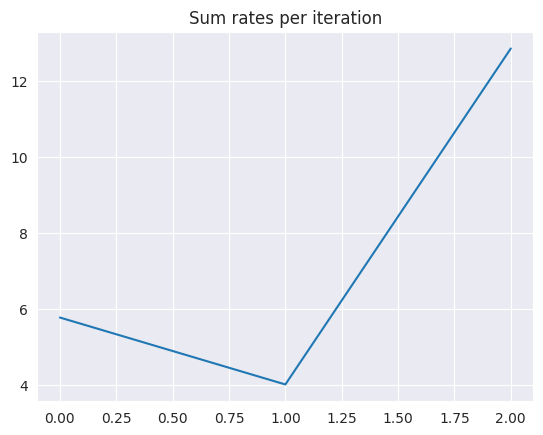

true
[np.float64(3.398169014356562), np.float64(4.786361439673527), np.float64(3.8297245182141433), np.float64(3.8835021531889318), np.float64(3.4075616525037464), np.float64(3.4491620339359574), np.float64(3.4965912098930043), np.float64(3.6302044381134055), np.float64(4.412539037265981), np.float64(3.4934363440755782), np.float64(3.400658601197601), np.float64(3.748465335021994), np.float64(5.139629402536697), np.float64(3.6300356564006524), np.float64(3.6277437261854684), np.float64(3.4092133088458194), np.float64(5.027049499840202), np.float64(3.4170321742639507), np.float64(4.502923022775599), np.float64(4.944350849683589), np.float64(3.4062124090309753), np.float64(3.4621694825953533), np.float64(3.8111917603800816), np.float64(3.9406445497690266), np.float64(3.728962618207989), np.float64(3.576123789119576), np.float64(3.8108124600548967), np.float64(80.91617840607587), np.float64(3.482571817867691), np.float64(3.414595156119741), np.float64(3.589829444172656), np.float64(3.8169

In [ ]:
import itertools
import tensorflow as tf


EPSILON_DECAY = 0.962

learning_rates = [1e-6]
agents = [semiConvAgent]
Envs=[UserScalableEnvWithTimeInfowithCommFix]
ITERATION_COUNT = 100
STEP_COUNT= 40
COLLECT_STEP_COUNT = STEP_COUNT
batch_sizes = [10]
UAV_MOVEMENT_SCALE = 20
UNIT =20
PENALTY = -100
EPSILON_MIN = 0.1
GAMMA=0.95  # Gamma daha da azaltırsa daha iyi sonuçlar çıkabilir

combinations = itertools.product(learning_rates,Envs,
                              batch_sizes,agents)
for comb in combinations:
    print(comb)
    LR = comb[0]
    env = comb[1]
    batch_size = comb[2]
    agent = comb[3]

    name = get_name(lr=LR,env=env.__name__,env_dim=env_dim,
            step_count=STEP_COUNT, iteration_count =ITERATION_COUNT,
            uav_movement_scale=UAV_MOVEMENT_SCALE, batch_size=batch_size,
            agent_class=agent.__name__, collect_step_size=COLLECT_STEP_COUNT,
            epsilon_decay=EPSILON_DECAY, epsilon_min=EPSILON_MIN,
            gamma=GAMMA)

    environment = env(uav_paths, ue_paths,
                        env_dim, batch_size=batch_size, uav_class=agent)

    per_iter,per_step = simulate(environment,iteration_count=ITERATION_COUNT,
                              step_count=STEP_COUNT, batch_size = batch_size,
                              collect_step_size=COLLECT_STEP_COUNT, env_name = name)

    environment.save(name+"_endofsim")

    writeLog(lr=LR, env=env.__name__, per_iter=per_iter, per_step=per_step, env_dim=env_dim,
          step_count=STEP_COUNT, iteration_count =ITERATION_COUNT, uav_movement_scale=UAV_MOVEMENT_SCALE,
          LastMap = environment.get3DMap(), batch_size=batch_size, agent_class=agent.__name__,
            collect_step_size=COLLECT_STEP_COUNT, epsilon_decay=EPSILON_DECAY, epsilon_min=EPSILON_MIN, gamma=GAMMA)